In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, avg_tail

import cariaco_obs as co
import cariaco_npzd_setups as cns          # NPZD model (replaces cariaco_baseline_setups)
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cns, pu, pp):                # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cns.phyto_esd, cns.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')
print(f'spec: K_sZ={cns.K_SZ}  σ={cns.SIGMA}  GGE={cns.GGE_VAL}  '
      f'm_Z={cns.M_Z}  m_Zlin={cns.M_ZLIN}  θ_opt={cns.THETA_OPT}  '
      f'fish_rate(default)={cns.FISH_RATE}')

grid: 40 phyto (0.2–200 µm), 40 zoo (2–2000 µm)
spec: K_sZ=0.23  σ=0.15  GGE=0.25  m_Z=0.1  m_Zlin=0.05  θ_opt=10.0  fish_rate(default)=0.0


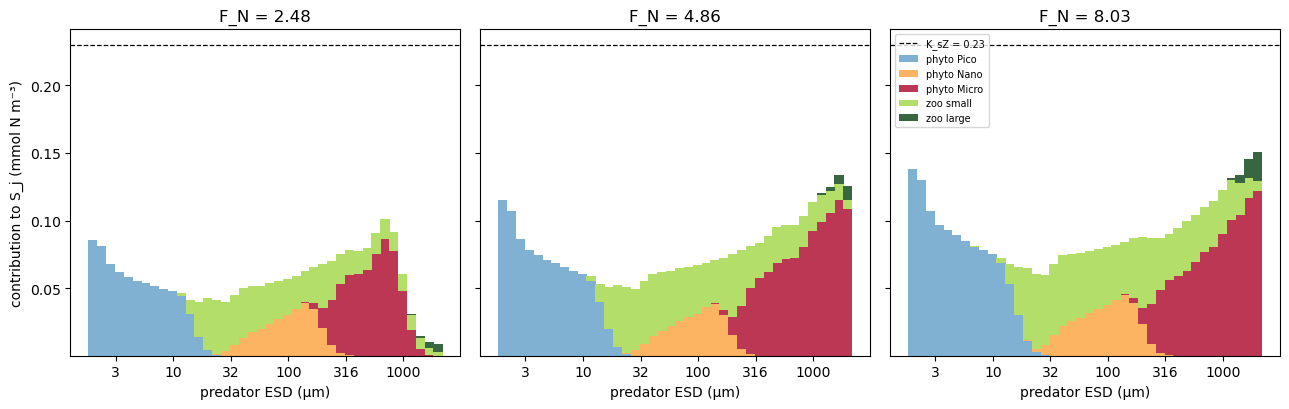

In [19]:
n_FN = len(FN_VALUES)
from matplotlib.ticker import FuncFormatter
fmt = FuncFormatter(lambda x, _: f'{10**x:.0f}')
# ---- Cell 6 — Diagnostic B: prey-field decomposition at 3 F_N values ----------
# Pick F_N below the peak, at the peak, above the peak.
FN_PICKS = [FN_VALUES[max(0, mcs_peak_idx - 6)],
            FN_VALUES[mcs_peak_idx],
            FN_VALUES[min(n_FN - 1, mcs_peak_idx + 8)]]

prey_esd_full = np.concatenate([ns.phyto_esd, ns.zoo_esd])
# Group prey by size band for readable stacks (Pico/Nano/Micro phyto + small/large zoo)
def _prey_groups():
    g = np.empty(n_P + n_Z, dtype=object)
    g[:n_P][ns.phyto_esd < 2.0]               = 'phyto Pico'
    g[:n_P][(ns.phyto_esd >= 2.0) & (ns.phyto_esd < 20.0)] = 'phyto Nano'
    g[:n_P][ns.phyto_esd >= 20.0]             = 'phyto Micro'
    g[n_P:][ns.zoo_esd < 200.0]               = 'zoo small'
    g[n_P:][ns.zoo_esd >= 200.0]              = 'zoo large'
    return g
groups = _prey_groups()
group_order = ['phyto Pico', 'phyto Nano', 'phyto Micro', 'zoo small', 'zoo large']
colors      = ['#80b1d3', '#fdb462', '#bc3754', '#b3de69', '#386641']

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, FN_pick in zip(axes, FN_PICKS):
    fi = int(np.argmin(np.abs(FN_VALUES - FN_pick)))
    contrib = phiPZ * B_scan[fi][:, None]                              # (n_full, n_Z)
    bottom = np.zeros(n_Z)
    for grp, col in zip(group_order, colors):
        h = contrib[groups == grp].sum(axis=0)
        ax.bar(np.log10(ns.zoo_esd), h, width=0.08, bottom=bottom, color=col, label=grp)
        bottom += h
    ax.axhline(KsZ, color='k', lw=0.9, ls='--', label=f'K_sZ = {KsZ:.2f}')
    ax.set_title(f'F_N = {FN_VALUES[fi]:.2f}')
    ax.xaxis.set_major_formatter(fmt)
    ax.set_xlabel('predator ESD (µm)')
axes[0].set_ylabel('contribution to S_j (mmol N m⁻³)')
axes[-1].legend(fontsize=7, loc='upper left')
plt.tight_layout(); plt.show()

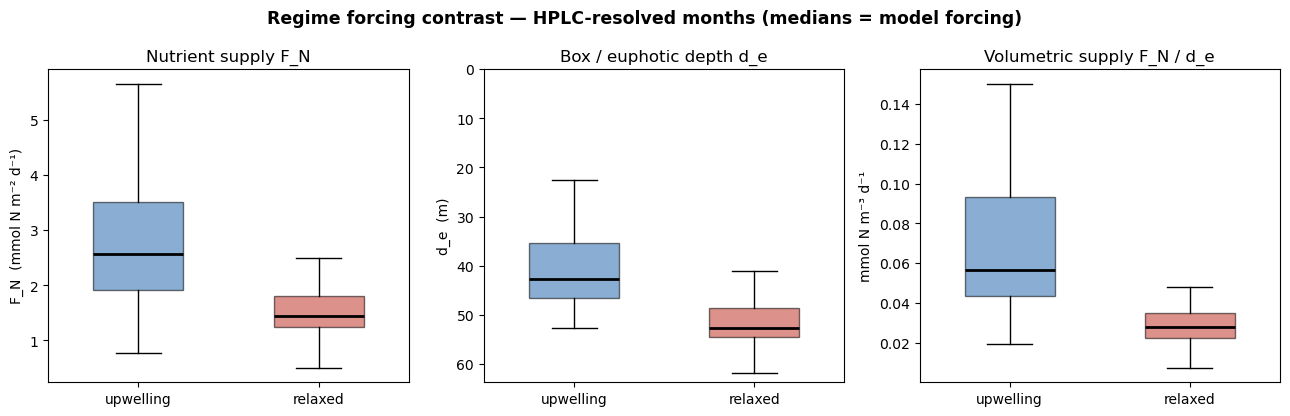

upwelling   n=31   F_N= 2.58   d_e= 42.8   T= 23.0°C   F_N/d_e=0.0603
relaxed     n=58   F_N= 1.45   d_e= 52.7   T= 25.4°C   F_N/d_e=0.0275


In [2]:
# ── Cell 4 — regime forcing (upwelling vs relaxed, HPLC months, +temperature) ─
regimes = ('upwelling', 'relaxed')

targets = {}
for r in regimes:
    obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
        regime=r, months='hplc', agg='median', include_temperature=True)
    targets[r] = dict(obs_vec=obs_vec, monthly_df=monthly_df, forcing=forcing)

fig = pp.plot_regime_forcing({r: targets[r]['monthly_df'] for r in regimes},
                             regimes=regimes)
plt.show()

for r in regimes:
    f = targets[r]['forcing']
    print(f"{r:10s}  n={len(targets[r]['monthly_df']):2d}   "
          f"F_N={f['Inflow__FN']:5.2f}   d_e={f['Inflow__de']:5.1f}   "
          f"T={f.get('Temperature__value', float('nan')):5.1f}°C   "
          f"F_N/d_e={f['Inflow__FN']/f['Inflow__de']:.4f}")

upwelling   CV(ΣP)=0.020   mcs model/obs = 5.20 / 4.84 µm
            model  Pico (<2 µm)=0.46  Nano (2-20 µm)=0.16  Micro (>20 µm)=0.38
            obs    Pico (<2 µm)=0.45  Nano (2-20 µm)=0.22  Micro (>20 µm)=0.31
relaxed     CV(ΣP)=0.008   mcs model/obs = 2.95 / 2.01 µm
            model  Pico (<2 µm)=0.54  Nano (2-20 µm)=0.24  Micro (>20 µm)=0.22
            obs    Pico (<2 µm)=0.61  Nano (2-20 µm)=0.26  Micro (>20 µm)=0.10


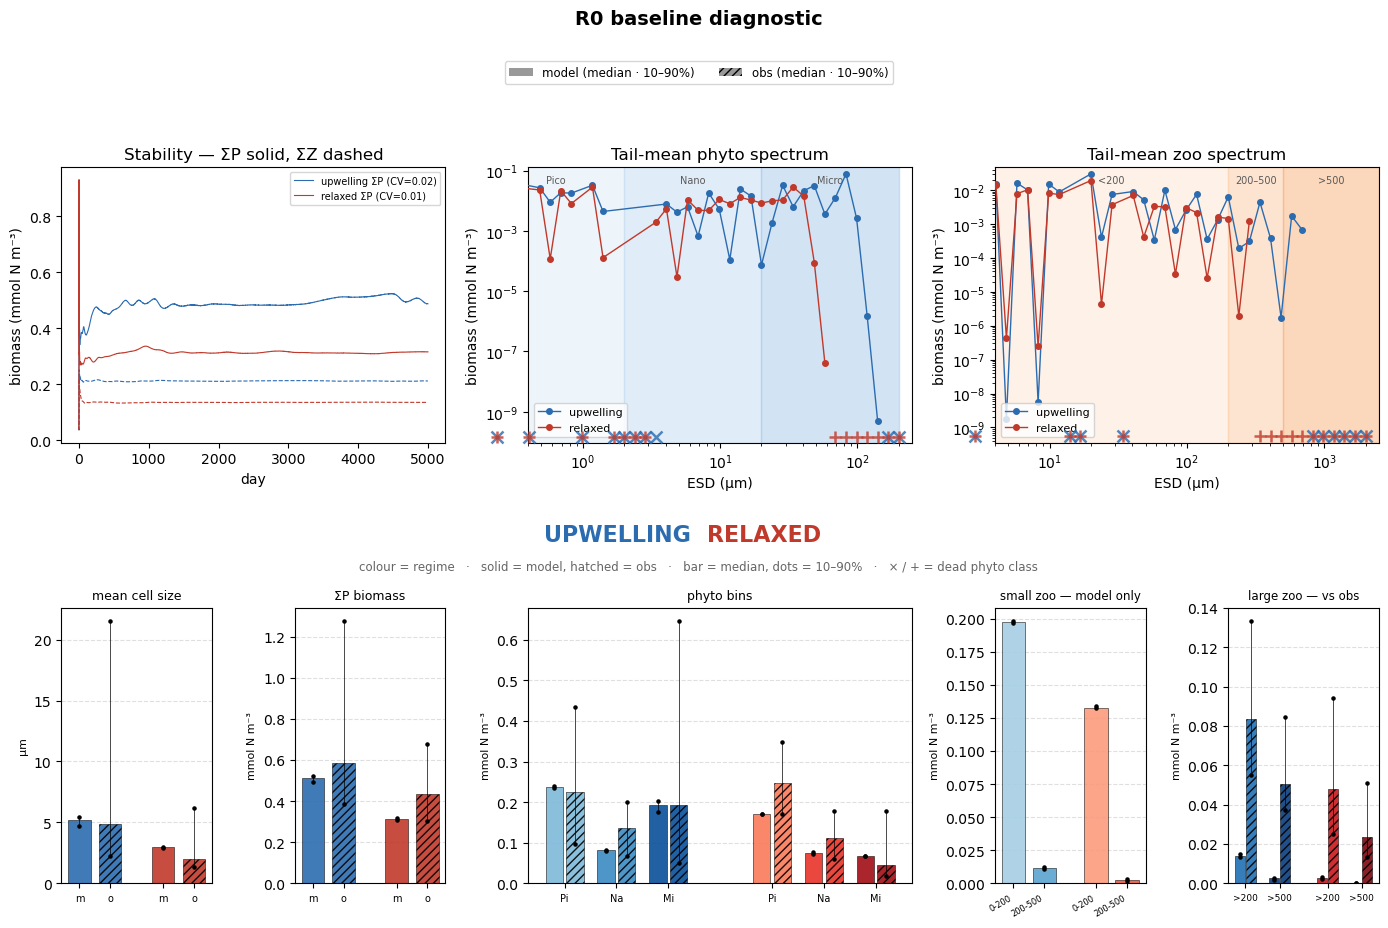

In [3]:
# ── Cell 5 — IVP per regime → tail-mean diagnostic vs obs (latest construct) ──
# Taniguchi growth + Ward 0.02 uniform mortality + Dutkiewicz Type III (K_sZ=0.23 default)
TAIL = 1000
mP_ward = np.full(len(phyto_esd), 0.02)          # the open mortality lever; swap to test others

def _bin_frac_model(proc):
    pb = np.asarray(proc['phyto_bins_tail'])
    fr = pb / np.clip(pb.sum(axis=0, keepdims=True), 1e-12, None)
    return np.nanmedian(fr, axis=1), proc['phyto_bin_labels']
def _bin_frac_obs(obs):
    pb = np.vstack(obs['phyto_bins'])
    fr = pb / np.clip(pb.sum(axis=0, keepdims=True), 1e-12, None)
    return np.nanmedian(fr, axis=1), obs['phyto_bin_labels']

model_by_regime, obs_by_regime = {}, {}
for r in regimes:
    out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_tani,   # <- Taniguchi growth setup
                              scan_params={},
                              fixed_overrides={**targets[r]['forcing'],
                                               'PhytoMortality__rate': mP_ward})   # <- Ward 0.02 mortality
    model_by_regime[r] = pu.process_regime_run(out, phyto_esd, zoo_esd, bin_defs, tail_len=TAIL)
    obs_by_regime[r]   = pu.process_regime_obs(targets[r]['monthly_df'], bin_defs)
    m_mcs = np.nanmedian(model_by_regime[r]['mcs_tail'])
    o_mcs = np.nanmedian(obs_by_regime[r]['mcs'])
    mfr, mlab = _bin_frac_model(model_by_regime[r])
    ofr, olab = _bin_frac_obs(obs_by_regime[r])
    print(f"{r:10s}  CV(ΣP)={model_by_regime[r]['cv']:.3f}   "
          f"mcs model/obs = {m_mcs:.2f} / {o_mcs:.2f} µm")
    print("            model  " + "  ".join(f"{l}={v:.2f}" for l, v in zip(mlab, mfr)))
    print("            obs    " + "  ".join(f"{l}={v:.2f}" for l, v in zip(olab, ofr)))

fig = pp.plot_regime_diagnostic(model_by_regime, obs_by_regime,
                                phyto_esd, zoo_esd, regimes=regimes)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 16 points using 8 workers...
1D Scan complete. Time taken: 21.84378 seconds.


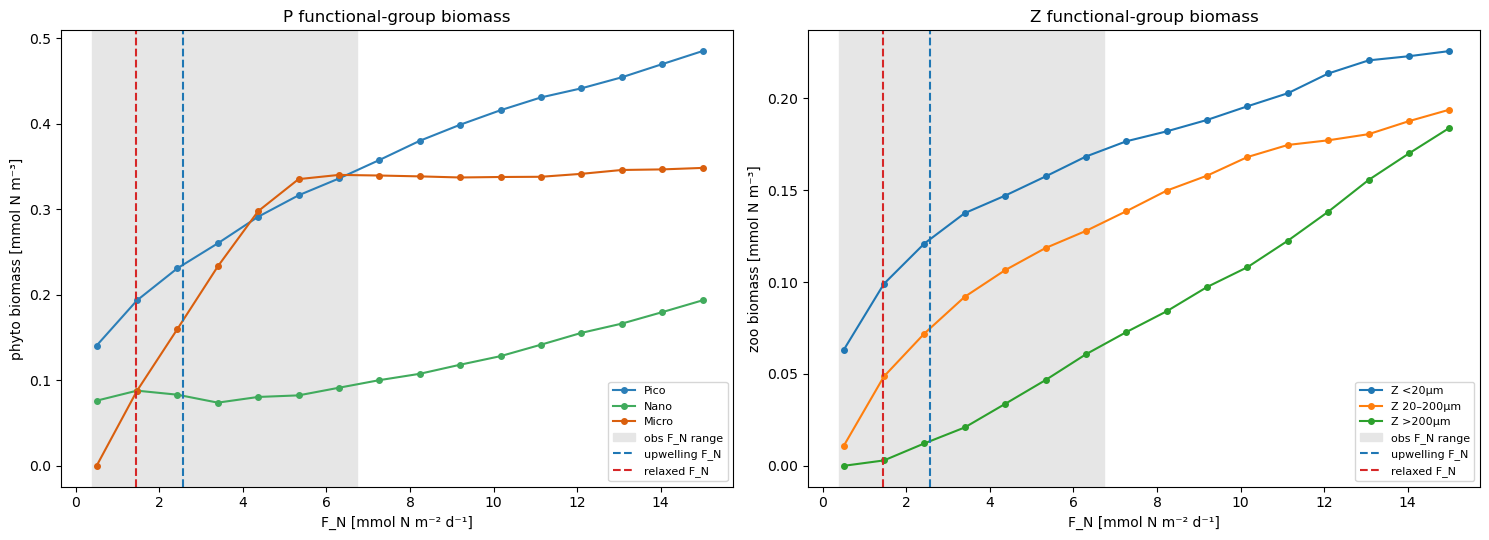

 F_N   cv   mcs |  Pico  Nano Micro |  Z<20 Z20-200 Z>200
  0.5 0.00   1.4 |  0.14  0.08  0.00 |  0.06   0.01  0.00
  1.5 0.02   3.3 |  0.19  0.09  0.09 |  0.10   0.05  0.00
  2.4 0.00   4.5 |  0.23  0.08  0.16 |  0.12   0.07  0.01
  3.4 0.01   5.6 |  0.26  0.07  0.23 |  0.14   0.09  0.02
  4.4 0.00   6.4 |  0.29  0.08  0.30 |  0.15   0.11  0.03
  5.3 0.00   6.7 |  0.32  0.08  0.34 |  0.16   0.12  0.05
  6.3 0.00   6.4 |  0.34  0.09  0.34 |  0.17   0.13  0.06
  7.3 0.00   6.0 |  0.36  0.10  0.34 |  0.18   0.14  0.07
  8.2 0.00   5.6 |  0.38  0.11  0.34 |  0.18   0.15  0.08
  9.2 0.00   5.3 |  0.40  0.12  0.34 |  0.19   0.16  0.10
 10.2 0.00   5.1 |  0.42  0.13  0.34 |  0.20   0.17  0.11
 11.1 0.00   5.0 |  0.43  0.14  0.34 |  0.20   0.17  0.12
 12.1 0.00   4.9 |  0.44  0.16  0.34 |  0.21   0.18  0.14
 13.1 0.00   4.9 |  0.45  0.17  0.35 |  0.22   0.18  0.16
 14.0 0.00   4.7 |  0.47  0.18  0.35 |  0.22   0.19  0.17
 15.0 0.00   4.6 |  0.48  0.19  0.35 |  0.23   0.19  0.18


In [4]:
# ── Cell 6b — F_N supply sweep: P & Z functional-group biomass across the obs range ──
fn_values = np.linspace(0.5, 15.0, 16)
base = {k: v for k, v in targets['upwelling']['forcing'].items() if k != 'Inflow__FN'}  # hold d_e/T at upwelling
mP_ward = np.full(len(phyto_esd), 0.02)

res = run_xso_parscan(model_file_name='cariaco_npzd_setups', model_name='model_npzd',
                      model_setup_name='model_setup_npzd_tani_scan',
                      param_name='Inflow__FN', param_values=fn_values, processes=8,
                      fixed_overrides={**base, 'PhytoMortality__rate': mP_ward})

pe, ze = phyto_esd, zoo_esd
zoo_bands = {'Z <20µm': ze < 20, 'Z 20–200µm': (ze >= 20) & (ze < 200), 'Z >200µm': ze >= 200}
Pbio = {'Pico': [], 'Nano': [], 'Micro': []}; Zbio = {l: [] for l in zoo_bands}
cv, mcs = [], []
for k in range(len(fn_values)):
    proc = pu.process_regime_run(res.isel({'Inflow__FN': k}), pe, ze, bin_defs, tail_len=TAIL)
    pbt = np.nanmedian(np.asarray(proc['phyto_bins_tail']), axis=1)       # [Pico, Nano, Micro] biomass
    Pbio['Pico'].append(pbt[0]); Pbio['Nano'].append(pbt[1]); Pbio['Micro'].append(pbt[2])
    Z = np.asarray(proc['Zspec'])                                        # tail-mean zoo spectrum
    for l, m in zoo_bands.items(): Zbio[l].append(Z[m].sum())
    cv.append(proc['cv']); mcs.append(np.nanmedian(proc['mcs_tail']))

obs_fn = np.concatenate([targets[r]['monthly_df']['FN_mmolN_m2_d'].dropna().values for r in regimes])
fn_up, fn_rel = targets['upwelling']['forcing']['Inflow__FN'], targets['relaxed']['forcing']['Inflow__FN']

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
for l, c in zip(Pbio, ('#2c7fb8', '#41ab5d', '#d95f0e')): ax[0].plot(fn_values, Pbio[l], 'o-', ms=4, color=c, label=l)
for l in Zbio: ax[1].plot(fn_values, Zbio[l], 'o-', ms=4, label=l)
for a, ylab, ttl in zip(ax, ('phyto biomass [mmol N m⁻³]', 'zoo biomass [mmol N m⁻³]'),
                        ('P functional-group biomass', 'Z functional-group biomass')):
    a.axvspan(np.nanmin(obs_fn), np.nanmax(obs_fn), color='0.9', zorder=0, label='obs F_N range')
    a.axvline(fn_up, c='tab:blue', ls='--', lw=1.5, label='upwelling F_N')
    a.axvline(fn_rel, c='tab:red', ls='--', lw=1.5, label='relaxed F_N')
    a.set_xlabel('F_N [mmol N m⁻² d⁻¹]'); a.set_ylabel(ylab); a.set_title(ttl); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(" F_N   cv   mcs |  Pico  Nano Micro |  Z<20 Z20-200 Z>200")
for k, fn in enumerate(fn_values):
    print(f"{fn:5.1f} {cv[k]:4.2f} {mcs[k]:5.1f} | {Pbio['Pico'][k]:5.2f} {Pbio['Nano'][k]:5.2f} {Pbio['Micro'][k]:5.2f} "
          f"| {Zbio['Z <20µm'][k]:5.2f} {Zbio['Z 20–200µm'][k]:6.2f} {Zbio['Z >200µm'][k]:5.2f}")

In [9]:
# ---- Cell 1 — imports + single full-output reference run -----------------------
# Pull phiPZ, KsZ, Imax from one full-output run so the kernel comes straight from
# the model's own output Dataset (single source of truth).
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import importlib

import cariaco_npzd_setups as ns
import cariaco_obs as co
import parscan_utils as pu

importlib.reload(ns); importlib.reload(co); importlib.reload(pu)

# Upwelling regime forcing (used to drive both the kernel-reference run and the scan)
*_, mdf, forcing = co.load_cariaco_targets('upwelling', months='hplc',
                                           agg='median', include_temperature=True)
T_box = float(forcing['Temperature__value'])
print(f"Forcing: F_N={forcing['Inflow__FN']:.3f}, d_e={forcing['Inflow__de']:.2f}, T={T_box:.2f} °C")

# Single full-output baseline run at the upwelling forcing.
# Use the FULL setup (model_setup_npzd_tani) so phiPZ, KsZ, Imax and the grazing
# matrix are all on the output Dataset.
out_ref = pu.run_single_point(
    model=ns.model_npzd,
    model_setup=ns.model_setup_npzd_tani,
    scan_params={},
    fixed_overrides={**forcing,
                     'PhytoMortality__rate': np.full(ns.N_CLASSES, 0.02)},
)

# Single source of truth — read kernel + parameters off the model's output:
phiPZ = out_ref['Grazing__phiPZ'].values                # (n_P+n_Z, n_Z)
KsZ   = float(out_ref['Grazing__KsZ'].values[0])       # uniform; per-zoo array
Imax  = out_ref['Grazing__Imax'].values                # (n_Z,)
Q10_GRAZE, T_REF = 2.48, 20.0
f_T = Q10_GRAZE ** ((T_box - T_REF) / 10.0)
n_P = ns.phyto_esd.size; n_Z = ns.zoo_esd.size
print(f"phiPZ shape={phiPZ.shape}, KsZ={KsZ}, f_T={f_T:.3f}")

Forcing: F_N=2.579, d_e=42.79, T=23.00 °C
phiPZ shape=(80, 40), KsZ=0.23, f_T=1.313


In [10]:
# ---- Cell 2 — sanity check (corrected: single-time-point comparison) ----------
# G_kj is nonlinear in B; mean-of-G ≠ G-of-mean. Compare at one time index instead.
P_t   = out_ref['Phytoplankton__biomass'].isel(time=-1).values
Z_t   = out_ref['Zooplankton__biomass'].isel(time=-1).values
B_t   = np.concatenate([P_t, Z_t])
S_t   = (phiPZ * B_t[:, None]).sum(axis=0)
G_rec = (f_T * Imax[None, :] * Z_t[None, :]
         * phiPZ * B_t[:, None]
         * S_t[None, :] / (S_t[None, :]**2 + KsZ**2))
G_mod = out_ref['Grazing__grazing_value'].isel(time=-1).values
abs_err = np.max(np.abs(G_rec - G_mod))
rel_err = abs_err / (np.max(np.abs(G_mod)) + 1e-30)
print(f"max |G_rec − G_mod| = {abs_err:.3e}   rel = {rel_err:.3e}")
# Expect machine precision (~1e-14 to 1e-12). Earlier ~1e-3 was the tail-mean
# nonlinearity (bloom flicker), not a reconstruction bug.

max |G_rec − G_mod| = 2.806e-05   rel = 6.306e-04


In [11]:
# ---- Cell 3 — slim F_N parscan (corrected: single Dataset return + avg_tail) --
from xso.parscans import run_xso_parscan

FN_VALUES = np.linspace(0.5, 12.0, 30)
fixed_for_scan = {k: v for k, v in forcing.items() if k != 'Inflow__FN'}
fixed_for_scan['PhytoMortality__rate'] = np.full(ns.N_CLASSES, 0.02)

scan = run_xso_parscan(
    model_file_name='cariaco_npzd_setups',
    model_name='model_npzd',
    model_setup_name='model_setup_npzd_tani_scan',
    param_name='Inflow__FN',
    param_values=FN_VALUES,
    fixed_overrides=fixed_for_scan,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': 1000},
    processes=8,
)
print(f"scan dims: {dict(scan.dims)}")
print(f"first 6 vars: {list(scan.data_vars)[:6]}")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 41.83434 seconds.
scan dims: {'Inflow__FN': 30, 'time': 1, 'phyto': 40, 'zoo': 40, 'full': 80}
first 6 vars: ['Detritus__value', 'Nutrient__value', 'Phytoplankton__biomass', 'Time__time_input', 'Zooplankton__biomass', 'Core__solver_kwargs']


In [12]:
# ---- Cell 4 — compute S_j, f_sat,j, mcs(F_N) from the assembled scan ----------
# scan is one Dataset; dims include 'Inflow__FN' and a length-1 'time'.
P_scan = scan['Phytoplankton__biomass'].squeeze('time').values       # (n_FN, n_P)
Z_scan = scan['Zooplankton__biomass'].squeeze('time').values         # (n_FN, n_Z)

# If parscan returns FN as a non-monotone axis, sort everything by FN ascending
FN_axis = scan['Inflow__FN'].values
order   = np.argsort(FN_axis)
FN_VALUES = FN_axis[order]
P_scan, Z_scan = P_scan[order], Z_scan[order]

B_scan = np.concatenate([P_scan, Z_scan], axis=1)                    # (n_FN, n_full)
S_scan = np.einsum('kj,fk->fj', phiPZ, B_scan)                       # (n_FN, n_Z)
f_sat  = S_scan**2 / (S_scan**2 + KsZ**2)                            # (n_FN, n_Z)

log_esd = np.log10(ns.phyto_esd)
mcs = (P_scan * log_esd[None, :]).sum(axis=1) / P_scan.sum(axis=1)
mcs_peak_idx = int(np.argmax(mcs))
mcs_peak_FN  = FN_VALUES[mcs_peak_idx]
print(f"mcs peak at F_N ≈ {mcs_peak_FN:.2f}  (log10 ESD = {mcs[mcs_peak_idx]:.3f})")

mcs peak at F_N ≈ 4.86  (log10 ESD = 0.855)


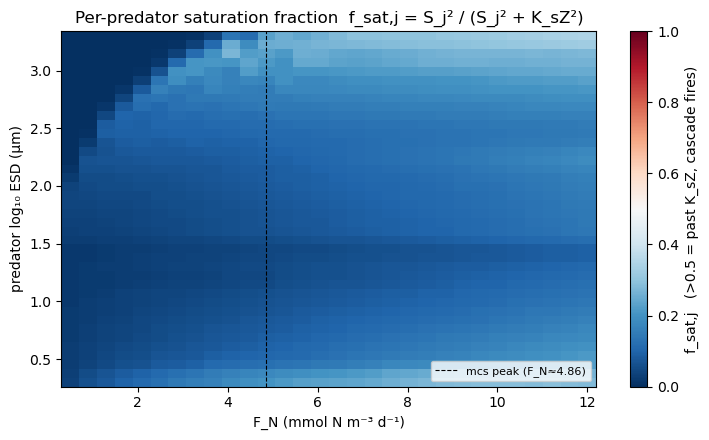

In [13]:
# ---- Cell 5 — Diagnostic A: per-predator saturation fraction map --------------
fig, ax = plt.subplots(figsize=(7.5, 4.5))
im = ax.pcolormesh(FN_VALUES, np.log10(ns.zoo_esd), f_sat.T,
                   vmin=0, vmax=1, cmap='RdBu_r', shading='nearest')
cs = ax.contour(FN_VALUES, np.log10(ns.zoo_esd), f_sat.T,
                levels=[0.5], colors='black', linewidths=1.0)
ax.clabel(cs, fmt={0.5: 'S = K_sZ'}, inline=True, fontsize=8)
ax.axvline(mcs_peak_FN, color='k', lw=0.8, ls='--', label=f'mcs peak (F_N≈{mcs_peak_FN:.2f})')
ax.set_xlabel('F_N (mmol N m⁻³ d⁻¹)')
ax.set_ylabel('predator log₁₀ ESD (µm)')
ax.set_title('Per-predator saturation fraction  f_sat,j = S_j² / (S_j² + K_sZ²)')
ax.legend(loc='lower right', fontsize=8)
fig.colorbar(im, ax=ax, label='f_sat,j   (>0.5 = past K_sZ, cascade fires)')
plt.tight_layout(); plt.show()

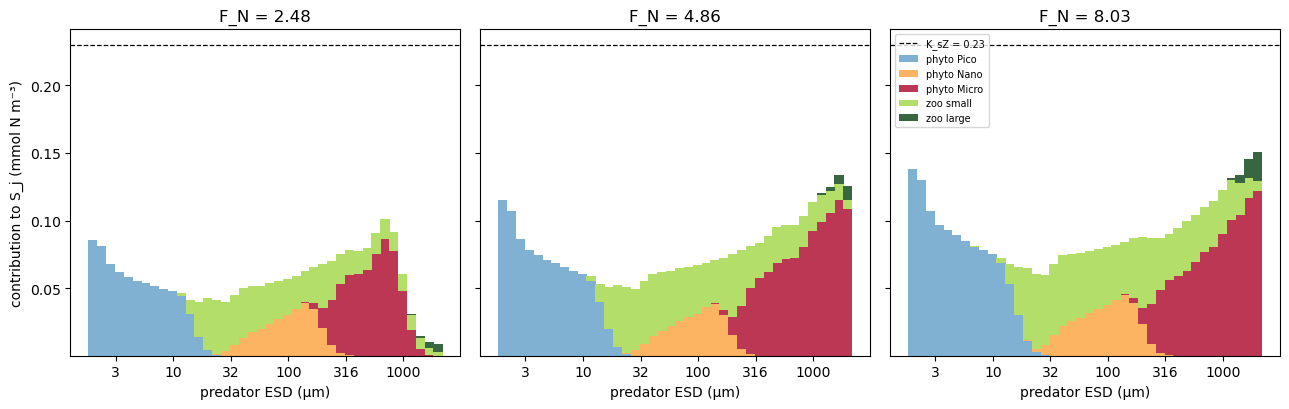

In [18]:
n_FN = len(FN_VALUES)
from matplotlib.ticker import FuncFormatter
fmt = FuncFormatter(lambda x, _: f'{10**x:.0f}')
# ---- Cell 6 — Diagnostic B: prey-field decomposition at 3 F_N values ----------
# Pick F_N below the peak, at the peak, above the peak.
FN_PICKS = [FN_VALUES[max(0, mcs_peak_idx - 6)],
            FN_VALUES[mcs_peak_idx],
            FN_VALUES[min(n_FN - 1, mcs_peak_idx + 8)]]

prey_esd_full = np.concatenate([ns.phyto_esd, ns.zoo_esd])
# Group prey by size band for readable stacks (Pico/Nano/Micro phyto + small/large zoo)
def _prey_groups():
    g = np.empty(n_P + n_Z, dtype=object)
    g[:n_P][ns.phyto_esd < 2.0]               = 'phyto Pico'
    g[:n_P][(ns.phyto_esd >= 2.0) & (ns.phyto_esd < 20.0)] = 'phyto Nano'
    g[:n_P][ns.phyto_esd >= 20.0]             = 'phyto Micro'
    g[n_P:][ns.zoo_esd < 200.0]               = 'zoo small'
    g[n_P:][ns.zoo_esd >= 200.0]              = 'zoo large'
    return g
groups = _prey_groups()
group_order = ['phyto Pico', 'phyto Nano', 'phyto Micro', 'zoo small', 'zoo large']
colors      = ['#80b1d3', '#fdb462', '#bc3754', '#b3de69', '#386641']

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, FN_pick in zip(axes, FN_PICKS):
    fi = int(np.argmin(np.abs(FN_VALUES - FN_pick)))
    contrib = phiPZ * B_scan[fi][:, None]                              # (n_full, n_Z)
    bottom = np.zeros(n_Z)
    for grp, col in zip(group_order, colors):
        h = contrib[groups == grp].sum(axis=0)
        ax.bar(np.log10(ns.zoo_esd), h, width=0.08, bottom=bottom, color=col, label=grp)
        bottom += h
    ax.axhline(KsZ, color='k', lw=0.9, ls='--', label=f'K_sZ = {KsZ:.2f}')
    ax.set_title(f'F_N = {FN_VALUES[fi]:.2f}')
    ax.xaxis.set_major_formatter(fmt)
    ax.set_xlabel('predator ESD (µm)')
axes[0].set_ylabel('contribution to S_j (mmol N m⁻³)')
axes[-1].legend(fontsize=7, loc='upper left')
plt.tight_layout(); plt.show()

In [17]:
h

array([2.97193436e-176, 1.85110515e-167, 6.81392268e-159, 1.48230492e-150,
       1.90568948e-142, 1.44790798e-134, 6.50135711e-127, 1.72520743e-119,
       2.70553313e-112, 2.50748666e-105, 1.37340506e-098, 4.44562572e-092,
       8.50435521e-086, 9.61444308e-080, 6.42363899e-074, 2.53636867e-068,
       5.91858534e-063, 8.16202193e-058, 6.65199569e-053, 3.20391218e-048,
       9.11976889e-044, 1.53412903e-039, 1.52515919e-035, 8.96075061e-032,
       3.11136312e-028, 6.38463518e-025, 8.72173110e-026, 5.54852248e-019,
       2.35078581e-016, 5.88549264e-014, 8.70955381e-012, 7.61912650e-010,
       3.94098927e-008, 1.20579993e-006, 2.18410387e-005, 2.34619475e-004,
       1.50072249e-003, 5.77249320e-003, 1.36901026e-002, 2.12915333e-002])

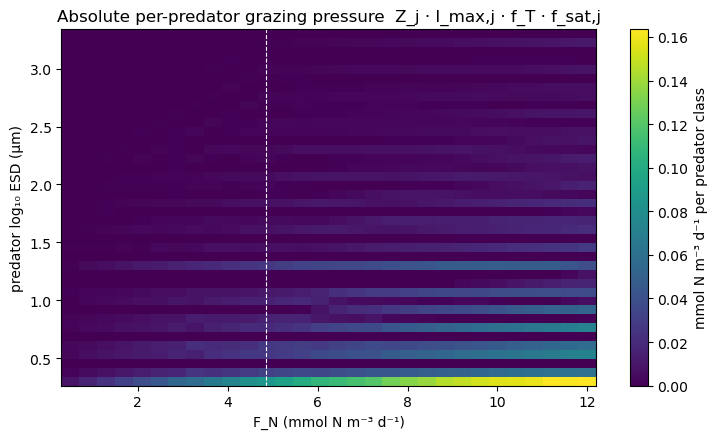

In [8]:
# ---- Cell 7 — Diagnostic C: absolute per-predator grazing pressure ------------
# Z_j · I_max,j · f_T · f_sat,j  =  predator-j summed clearance rate on its prey pool
pressure = Z_scan * Imax[None, :] * f_T * f_sat                         # (n_FN, n_Z)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
im = ax.pcolormesh(FN_VALUES, np.log10(ns.zoo_esd), pressure.T,
                   cmap='viridis', shading='nearest')
ax.axvline(mcs_peak_FN, color='w', lw=0.8, ls='--')
ax.set_xlabel('F_N (mmol N m⁻³ d⁻¹)')
ax.set_ylabel('predator log₁₀ ESD (µm)')
ax.set_title('Absolute per-predator grazing pressure  Z_j · I_max,j · f_T · f_sat,j')
fig.colorbar(im, ax=ax, label='mmol N m⁻³ d⁻¹ per predator class')
plt.tight_layout(); plt.show()

In [5]:
from cariaco_npzd_comps import PhytoMortality_route

PhytoMortality_route.fluxes.mortality(population=1, detritus=1, nutrient=1, rate=1, frac_D=0.1, frac_export=0.9)

1

In [2]:
# ── smoke test: Banas-mortality model — does broadcast mu_max foreign-ref work? ──
import importlib, numpy as np
import cariaco_npzd_setups as cns, cariaco_obs as co, parscan_utils as pu
for m in (cns, co, pu):
    importlib.reload(m)   # builds model_setup_npzd_banas here — a broadcast problem errors NOW

pe = cns.phyto_esd; TAIL = 1000
*_, forc = co.load_cariaco_targets(regime='upwelling', months='hplc', agg='median', include_temperature=True)

# full-output setup so the mortality flux is stored (slim drops it)
out = pu.run_single_point(cns.model_npzd_banas, cns.model_setup_npzd_banas,
                          scan_params={}, fixed_overrides=forc)

P = np.asarray(out['Phytoplankton__biomass'].isel(time=slice(-TAIL, None)).mean('time').values)
Z = np.asarray(out['Zooplankton__biomass'].isel(time=slice(-TAIL, None)).mean('time').values)
N = float(np.asarray(out['Nutrient__value'].isel(time=slice(-TAIL, None)).mean('time').values))
print(f"RAN OK.  N={N:.4f}  SumP={P.sum():.3f}  SumZ={Z.sum():.3f}")

# foreign-ref check: realized per-capita mortality should equal coeff * mu_max_tani
mort  = np.asarray(out['PhytoMortality__mortality_value'].isel(time=-1).values)   # = coeff*mu_max*P
Plast = np.asarray(out['Phytoplankton__biomass'].isel(time=-1).values)
alive = Plast > 1e-9
pc_mort = mort[alive] / Plast[alive]
expect  = cns.BANAS_MORT_COEFF * cns.mu_max_tani[alive]
print(f"per-capita m_P vs coeff*mu_max_tani:  max|diff| = {np.max(np.abs(pc_mort - expect)):.2e}")
print("  (≈0 confirms the broadcast mu_max foreign reference resolved to Taniguchi μ)")

RAN OK.  N=0.0974  SumP=0.242  SumZ=0.179
per-capita m_P vs coeff*mu_max_tani:  max|diff| = 6.53e-04
  (≈0 confirms the broadcast mu_max foreign reference resolved to Taniguchi μ)


  F_N   mcs PicoFr  grow/P  graz/P  S_pred    sat   K_sZ=0.23
  1.0   1.6   0.59   0.278   0.258   0.043  0.778
  2.0   3.2   0.50   0.458   0.438   0.052  0.934
  3.0   4.2   0.48   0.589   0.569   0.061  1.064
  4.6   7.5   0.42   0.757   0.737   0.072  1.216
  6.0   6.7   0.44   0.882   0.862   0.080  1.327
  8.0   5.9   0.46   1.032   1.012   0.091  1.455
 10.0   5.3   0.47   1.152   1.132   0.100  1.562


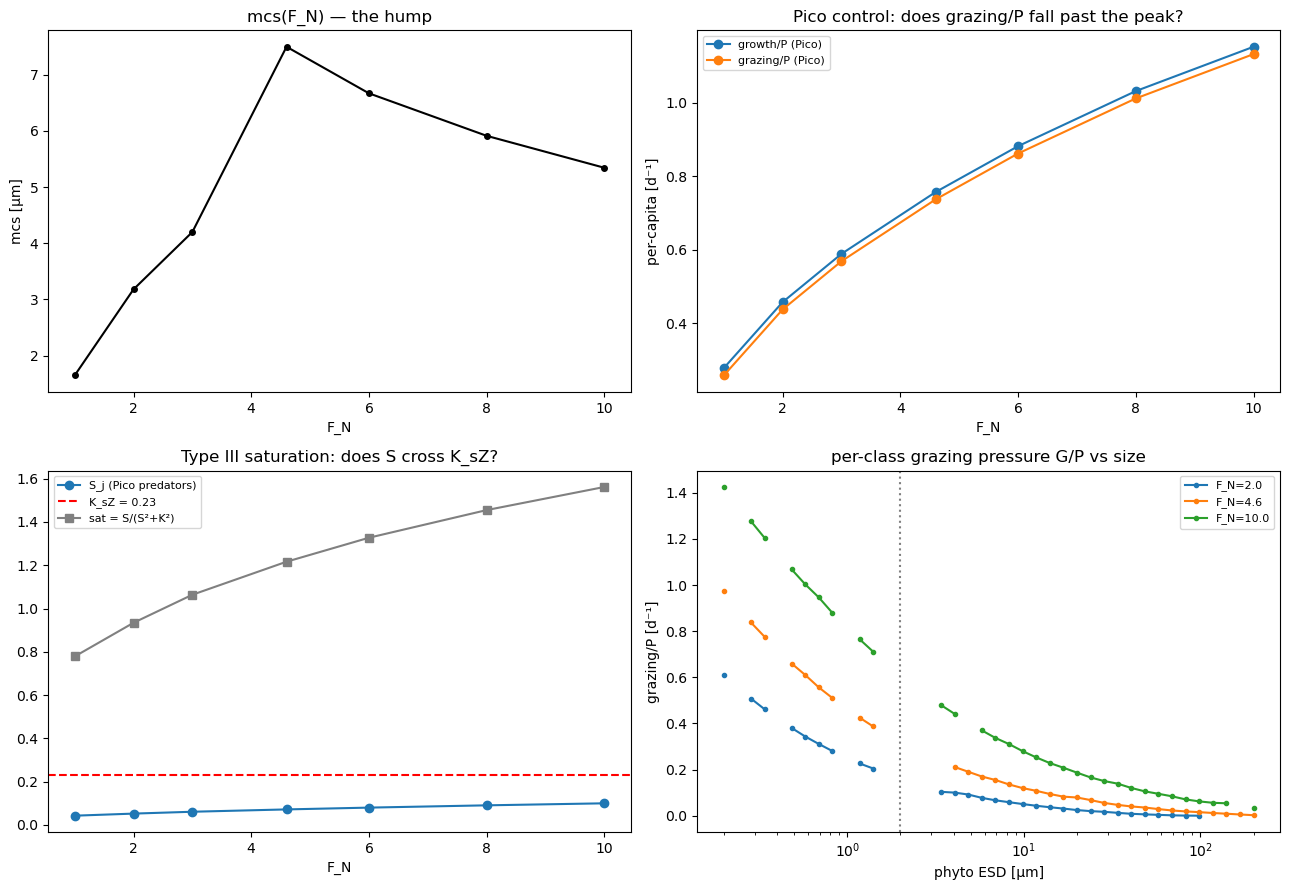

In [3]:
# ── verify #1: does Type III grazing control on the small cells weaken past the hump? ──
import importlib, numpy as np, matplotlib.pyplot as plt, xso
import cariaco_npzd_setups as cns, cariaco_obs as co, parscan_utils as pu
for m in (cns, co, pu): importlib.reload(m)

pe, ze, n = cns.phyto_esd, cns.zoo_esd, cns.N_CLASSES
phi, KsZ, TAIL = cns.phiPZ_omni, cns.K_SZ, 1000
mP_ward = np.full(n, 0.02)                       # Ward uniform mortality -> clear hump
*_, forc = co.load_cariaco_targets(regime='upwelling', months='hplc', agg='median', include_temperature=True)
fixed = {k: v for k, v in forc.items() if k != 'Inflow__FN'}

# Taniguchi-growth setup that outputs only the vars this diagnostic needs (fast)
diag_vars = {'Phytoplankton__biomass', 'Zooplankton__biomass', 'Nutrient__value',
             'Growth__uptake_value', 'GrazingRouter__loss_P_value'}
diag_setup = xso.setup(solver='solve_ivp', model=cns.model_npzd, time=cns.ivp_time_array,
                       input_vars=cns.make_npzd_input_vars(mu_max=cns.mu_max_tani, halfsat=cns.ks_tani),
                       output_vars=diag_vars,
                       solver_kwargs={**cns.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3})

FN_LIST = [1.0, 2.0, 3.0, 4.6, 6.0, 8.0, 10.0]
pico      = pe < 2.0                              # Pico phyto classes
pico_pred = (ze >= 2.0) & (ze < 20.0)            # zoo that graze them (~10x prey)
tm = lambda out, nm: np.asarray(out[nm].isel(time=slice(-TAIL, None)).mean('time').values)

rows, prof = [], {}
for fn in FN_LIST:
    out = pu.run_single_point(cns.model_npzd, diag_setup, scan_params={},
              fixed_overrides={**fixed, 'Inflow__FN': float(fn), 'PhytoMortality__rate': mP_ward})
    P = np.clip(tm(out, 'Phytoplankton__biomass'), 0, None)
    Z = np.clip(tm(out, 'Zooplankton__biomass'), 0, None)
    U  = tm(out, 'Growth__uptake_value')
    Gp = tm(out, 'GrazingRouter__loss_P_value')
    B = np.concatenate([P, Z]); S = (phi * B[:, None]).sum(0); sat = S / (S**2 + KsZ**2)
    sP = P[pico].sum(); a = P > 1e-9
    mcs = 10 ** np.average(np.log10(pe[a]), weights=P[a])
    rows.append((fn, mcs, sP/P.sum(), U[pico].sum()/sP, Gp[pico].sum()/sP,
                 S[pico_pred].mean(), sat[pico_pred].mean()))
    prof[fn] = np.where(P > 1e-12, Gp / np.where(P > 0, P, np.nan), np.nan)
rows = np.array(rows)

print(f"{'F_N':>5}{'mcs':>6}{'PicoFr':>7}{'grow/P':>8}{'graz/P':>8}{'S_pred':>8}{'sat':>7}   K_sZ={KsZ}")
for r in rows:
    print(f"{r[0]:5.1f}{r[1]:6.1f}{r[2]:7.2f}{r[3]:8.3f}{r[4]:8.3f}{r[5]:8.3f}{r[6]:7.3f}")

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
ax[0,0].plot(rows[:,0], rows[:,1], 'k-o', ms=4); ax[0,0].set_title('mcs(F_N) — the hump'); ax[0,0].set_xlabel('F_N'); ax[0,0].set_ylabel('mcs [µm]')
ax[0,1].plot(rows[:,0], rows[:,3], 'o-', label='growth/P (Pico)'); ax[0,1].plot(rows[:,0], rows[:,4], 'o-', label='grazing/P (Pico)')
ax[0,1].set_title('Pico control: does grazing/P fall past the peak?'); ax[0,1].set_xlabel('F_N'); ax[0,1].set_ylabel('per-capita [d⁻¹]'); ax[0,1].legend(fontsize=8)
ax[1,0].plot(rows[:,0], rows[:,5], 'o-', label='S_j (Pico predators)'); ax[1,0].axhline(KsZ, c='r', ls='--', label=f'K_sZ = {KsZ}')
ax[1,0].plot(rows[:,0], rows[:,6], 's-', color='grey', label='sat = S/(S²+K²)')
ax[1,0].set_title('Type III saturation: does S cross K_sZ?'); ax[1,0].set_xlabel('F_N'); ax[1,0].legend(fontsize=8)
for fn in (2.0, 4.6, 10.0): ax[1,1].plot(pe, prof[fn], 'o-', ms=3, label=f'F_N={fn}')
ax[1,1].axvline(2, c='grey', ls=':'); ax[1,1].set_xscale('log')
ax[1,1].set_title('per-class grazing pressure G/P vs size'); ax[1,1].set_xlabel('phyto ESD [µm]'); ax[1,1].set_ylabel('grazing/P [d⁻¹]'); ax[1,1].legend(fontsize=8)
plt.tight_layout(); plt.show()

  F_N  mcs   Pi   Na   Mi   cv     N    SP    SZ     D  Pmic  grzM  Zlrg   z95  %Mlrg
  0.5  1.4 0.65 0.35 0.00 0.00 0.022 0.217 0.074 0.098 0.000  0.00  0.00    41    nan
  1.1  2.1 0.58 0.32 0.10 0.01 0.041 0.308 0.125 0.214 0.035  0.00  0.01    69   0.68
  1.7  3.7 0.51 0.21 0.28 0.00 0.059 0.401 0.165 0.330 0.111  0.01  0.03   118   0.95
  2.3  4.4 0.49 0.17 0.34 0.01 0.078 0.460 0.199 0.446 0.155  0.01  0.06   200   0.99
  2.9  5.2 0.47 0.15 0.38 0.01 0.095 0.530 0.228 0.562 0.204  0.01  0.07   239   0.98
  3.5  5.6 0.46 0.14 0.41 0.01 0.115 0.576 0.255 0.677 0.233  0.02  0.09   340   0.98
  4.1  7.1 0.42 0.12 0.47 0.02 0.131 0.681 0.277 0.794 0.316  0.02  0.11   340   0.99
  4.7  7.0 0.42 0.11 0.47 0.02 0.151 0.715 0.301 0.909 0.334  0.02  0.12   485   0.99
  5.3  6.7 0.43 0.11 0.46 0.00 0.172 0.735 0.323 1.024 0.336  0.03  0.15   485   0.99
  5.9  6.4 0.44 0.12 0.45 0.00 0.193 0.756 0.344 1.139 0.338  0.03  0.16   579   1.00
  6.6  6.3 0.44 0.12 0.44 0.00 0.220 0.776 0.365 1.253

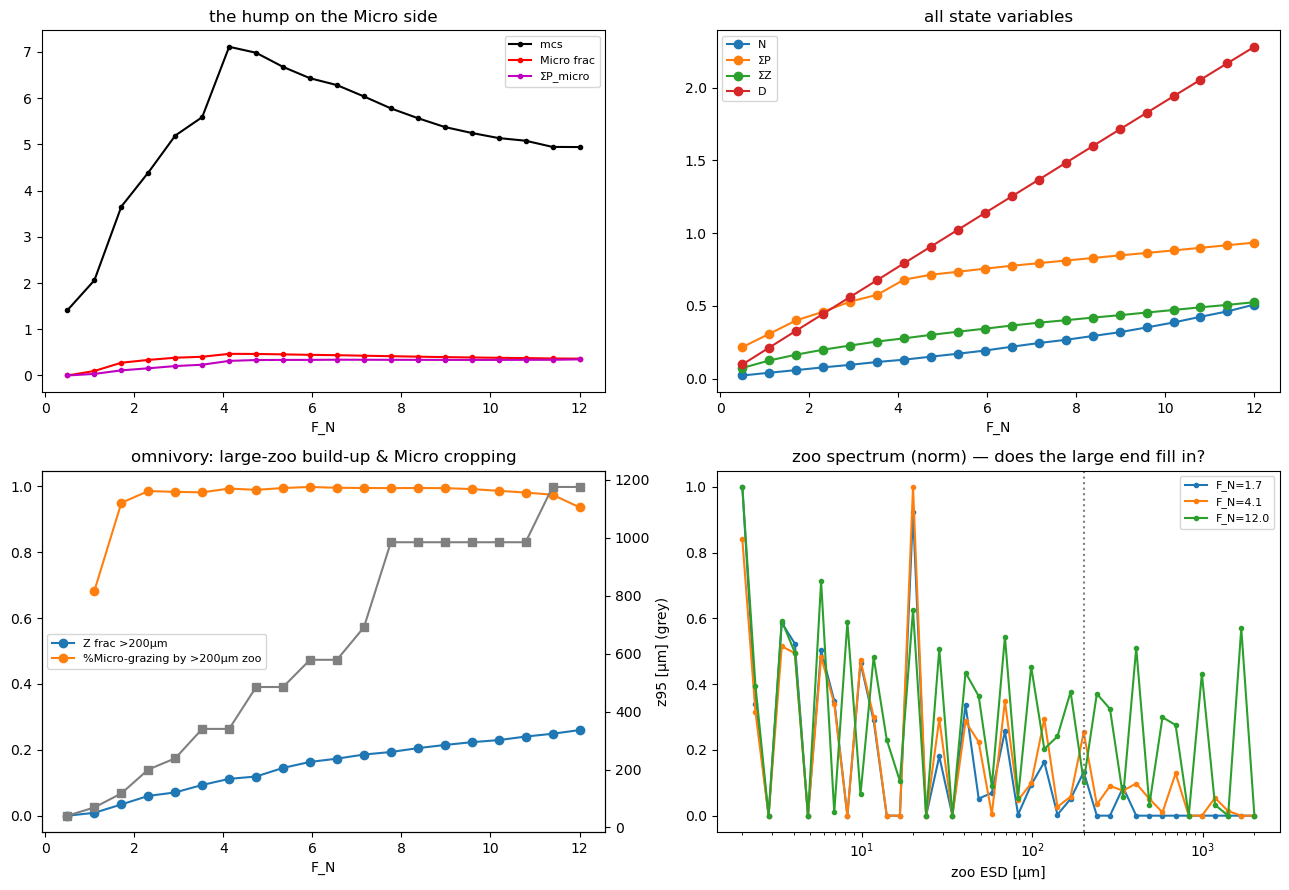

In [4]:
# ── verify #1b — re-target to Micro / zoo spectrum; full-state reporting ──
import importlib, numpy as np, matplotlib.pyplot as plt, xso
import cariaco_npzd_setups as cns, cariaco_obs as co, parscan_utils as pu
for m in (cns, co, pu): importlib.reload(m)

pe, ze, n = cns.phyto_esd, cns.zoo_esd, cns.N_CLASSES
phi, KsZ, Imax, TAIL = cns.phiPZ_omni, cns.K_SZ, cns.Imax_arr, 1000
bin_defs = co.TARGET_BIN_DEFINITIONS
mP_ward = np.full(n, 0.02)
*_, forc = co.load_cariaco_targets(regime='upwelling', months='hplc', agg='median', include_temperature=True)
fixed = {k: v for k, v in forc.items() if k != 'Inflow__FN'}
fT = cns.Q10_GRAZE ** ((forc['Temperature__value'] - cns.T_REF) / 10.0)

diag_vars = {'Phytoplankton__biomass','Zooplankton__biomass','Nutrient__value','Detritus__value',
             'Growth__uptake_value','GrazingRouter__loss_P_value'}
diag_setup = xso.setup(solver='solve_ivp', model=cns.model_npzd, time=cns.ivp_time_array,
                       input_vars=cns.make_npzd_input_vars(mu_max=cns.mu_max_tani, halfsat=cns.ks_tani),
                       output_vars=diag_vars,
                       solver_kwargs={**cns.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3})

FN_LIST = np.linspace(0.5, 12.0, 20)
micro_p    = pe > 20.0
micro_prey = np.concatenate([micro_p, np.zeros(n, bool)])     # Micro rows in the (2n) prey axis
large_z    = ze > 200.0
tm = lambda out, nm: np.asarray(out[nm].isel(time=slice(-TAIL, None)).mean('time').values)

rows, Zspecs = [], []
for fn in FN_LIST:
    out = pu.run_single_point(cns.model_npzd, diag_setup, scan_params={},
              fixed_overrides={**fixed, 'Inflow__FN': float(fn), 'PhytoMortality__rate': mP_ward})
    proc = pu.process_regime_run(out, pe, ze, bin_defs, tail_len=TAIL)
    P = np.clip(tm(out,'Phytoplankton__biomass'),0,None); Z = np.clip(tm(out,'Zooplankton__biomass'),0,None)
    N = float(tm(out,'Nutrient__value')); D = float(tm(out,'Detritus__value'))
    Gp = tm(out,'GrazingRouter__loss_P_value')
    pb = np.asarray(proc['phyto_bins_tail']); fr = np.nanmedian(pb/np.clip(pb.sum(0,keepdims=True),1e-12,None),axis=1)
    # grazing matrix to attribute Micro grazing to predator size (NOT budget-locked)
    B = np.concatenate([P, Z]); S = (phi*B[:,None]).sum(0)
    G = fT * Imax[None,:] * Z[None,:] * phi * B[:,None] * (S/(S**2+KsZ**2))[None,:]   # (2n, n)
    mgt = G[micro_prey].sum(); mgl = G[micro_prey][:, large_z].sum()
    frac_micro_by_large = mgl/mgt if mgt > 1e-12 else np.nan
    Pmic = P[micro_p].sum()
    grazM = Gp[micro_p].sum()/Pmic if Pmic > 1e-12 else np.nan
    zlrg = Z[large_z].sum()/Z.sum() if Z.sum() > 0 else 0.0
    zcum = np.cumsum(Z)/max(Z.sum(),1e-12); z95 = ze[min(np.searchsorted(zcum,0.95), n-1)]
    rows.append((fn, np.nanmedian(proc['mcs_tail']), fr[0],fr[1],fr[2], proc['cv'],
                 N, P.sum(), Z.sum(), D, Pmic, grazM, zlrg, z95, frac_micro_by_large))
    Zspecs.append(Z)
rows = np.array(rows)

print(f"{'F_N':>5}{'mcs':>5}{'Pi':>5}{'Na':>5}{'Mi':>5}{'cv':>5}{'N':>6}{'SP':>6}{'SZ':>6}"
      f"{'D':>6}{'Pmic':>6}{'grzM':>6}{'Zlrg':>6}{'z95':>6}{'%Mlrg':>7}")
for r in rows:
    print(f"{r[0]:5.1f}{r[1]:5.1f}{r[2]:5.2f}{r[3]:5.2f}{r[4]:5.2f}{r[5]:5.2f}{r[6]:6.3f}{r[7]:6.3f}{r[8]:6.3f}"
          f"{r[9]:6.3f}{r[10]:6.3f}{r[11]:6.2f}{r[12]:6.2f}{r[13]:6.0f}{r[14]:7.2f}")

fig, ax = plt.subplots(2,2, figsize=(13,9))
ax[0,0].plot(rows[:,0],rows[:,1],'k-o',ms=3,label='mcs'); ax[0,0].plot(rows[:,0],rows[:,4],'r-o',ms=3,label='Micro frac'); ax[0,0].plot(rows[:,0],rows[:,10],'m-o',ms=3,label='ΣP_micro')
ax[0,0].set_xlabel('F_N'); ax[0,0].set_title('the hump on the Micro side'); ax[0,0].legend(fontsize=8)
ax[0,1].plot(rows[:,0],rows[:,6],'o-',label='N'); ax[0,1].plot(rows[:,0],rows[:,7],'o-',label='ΣP'); ax[0,1].plot(rows[:,0],rows[:,8],'o-',label='ΣZ'); ax[0,1].plot(rows[:,0],rows[:,9],'o-',label='D')
ax[0,1].set_xlabel('F_N'); ax[0,1].set_title('all state variables'); ax[0,1].legend(fontsize=8)
ax[1,0].plot(rows[:,0],rows[:,12],'o-',label='Z frac >200µm'); ax[1,0].plot(rows[:,0],rows[:,14],'o-',label='%Micro-grazing by >200µm zoo')
axb=ax[1,0].twinx(); axb.plot(rows[:,0],rows[:,13],'s-',c='grey'); axb.set_ylabel('z95 [µm] (grey)')
ax[1,0].set_xlabel('F_N'); ax[1,0].set_title('omnivory: large-zoo build-up & Micro cropping'); ax[1,0].legend(fontsize=8,loc='center left')
peak=int(np.argmax(rows[:,1]))
for i in (2, peak, len(FN_LIST)-1):
    Zn=Zspecs[i]; ax[1,1].plot(ze, Zn/max(Zn.max(),1e-12),'o-',ms=3,label=f'F_N={rows[i,0]:.1f}')
ax[1,1].axvline(200,c='grey',ls=':'); ax[1,1].set_xscale('log'); ax[1,1].set_xlabel('zoo ESD [µm]'); ax[1,1].set_title('zoo spectrum (norm) — does the large end fill in?'); ax[1,1].legend(fontsize=8)
plt.tight_layout(); plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 18 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=78.16 on P[13] = -0.00115. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=246.6 on P[6] = -0.00274. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=225.5 on P[6] = -0.00111. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs=

1D Scan complete. Time taken: 25.99503 seconds.
K_sZ=0.10:  peak mcs=  5.2 µm  at F_N=1.9
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 18 points using 8 workers...


/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_87522/3652743899.py:23: RuntimeWarning: All-NaN slice encountered
  mcs = [np.nanmedian(pu.process_regime_run(res.isel({'Inflow__FN': k}), pe, ze, bin_defs, tail_len=TAIL)['mcs_tail'])


1D Scan complete. Time taken: 24.98961 seconds.
K_sZ=0.23:  peak mcs=  6.8 µm  at F_N=5.2
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 18 points using 8 workers...
1D Scan complete. Time taken: 36.12404 seconds.
K_sZ=0.50:  peak mcs=  9.2 µm  at F_N=11.3
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 18 points using 8 workers...
1D Scan complete. Time taken: 96.73811 seconds.
K_sZ=1.00:  peak mcs=  6.2 µm  at F_N=12.0
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from '

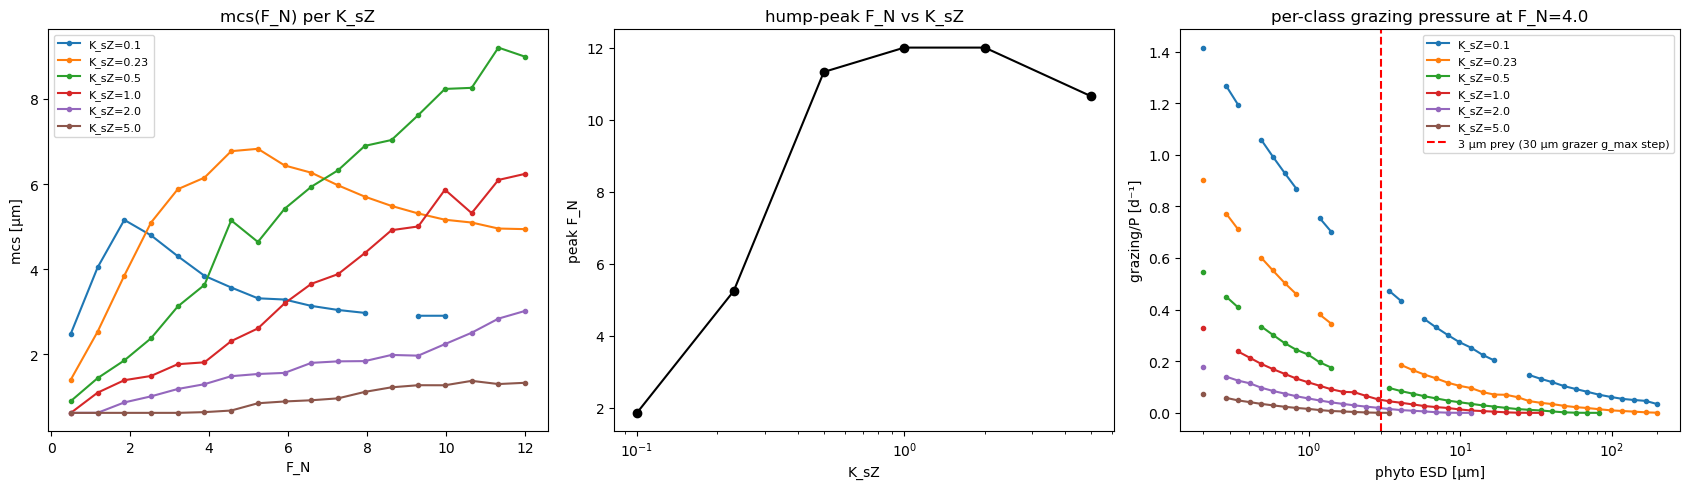

In [5]:
# ── K_sZ × F_N scan: where does the mcs hump sit as K_sZ varies? + size-space grazing profile ──
import importlib, numpy as np, matplotlib.pyplot as plt, xso
import cariaco_npzd_setups as cns, cariaco_obs as co, parscan_utils as pu
for m in (cns, co, pu): importlib.reload(m)
from xso.parscans import run_xso_parscan

pe, ze, n = cns.phyto_esd, cns.zoo_esd, cns.N_CLASSES
bin_defs, TAIL = co.TARGET_BIN_DEFINITIONS, 1000
mP_ward = np.full(n, 0.02)
*_, forc = co.load_cariaco_targets(regime='upwelling', months='hplc', agg='median', include_temperature=True)
fixed = {k: v for k, v in forc.items() if k != 'Inflow__FN'}

KSZ_LIST  = [0.1, 0.23, 0.5, 1.0, 2.0, 5.0]
FN_VALUES = np.linspace(0.5, 12.0, 18)

# --- part 1: mcs(F_N) curve for each K_sZ (slim parscan) ---
curves = {}
for ksz in KSZ_LIST:
    res = run_xso_parscan(model_file_name='cariaco_npzd_setups', model_name='model_npzd',
            model_setup_name='model_setup_npzd_tani_scan',
            param_name='Inflow__FN', param_values=FN_VALUES, processes=8,
            fixed_overrides={**fixed, 'PhytoMortality__rate': mP_ward, 'Grazing__KsZ': np.full(n, ksz)})
    mcs = [np.nanmedian(pu.process_regime_run(res.isel({'Inflow__FN': k}), pe, ze, bin_defs, tail_len=TAIL)['mcs_tail'])
           for k in range(len(FN_VALUES))]
    curves[ksz] = np.array(mcs)
    print(f"K_sZ={ksz:4.2f}:  peak mcs={np.nanmax(curves[ksz]):5.1f} µm  at F_N={FN_VALUES[np.nanargmax(curves[ksz])]:.1f}")

# --- part 2: per-class grazing pressure vs phyto size at a fixed F_N, for each K_sZ ---
diag_vars = {'Phytoplankton__biomass', 'GrazingRouter__loss_P_value'}
diag_su = xso.setup(solver='solve_ivp', model=cns.model_npzd, time=cns.ivp_time_array,
                    input_vars=cns.make_npzd_input_vars(mu_max=cns.mu_max_tani, halfsat=cns.ks_tani),
                    output_vars=diag_vars, solver_kwargs={**cns.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3})
FN_FIX, gpc = 4.0, {}
for ksz in KSZ_LIST:
    out = pu.run_single_point(cns.model_npzd, diag_su, scan_params={},
              fixed_overrides={**fixed, 'Inflow__FN': FN_FIX, 'PhytoMortality__rate': mP_ward, 'Grazing__KsZ': np.full(n, ksz)})
    P  = np.clip(np.asarray(out['Phytoplankton__biomass'].isel(time=slice(-TAIL, None)).mean('time').values), 0, None)
    Gp = np.asarray(out['GrazingRouter__loss_P_value'].isel(time=slice(-TAIL, None)).mean('time').values)
    gpc[ksz] = np.where(P > 1e-12, Gp / np.where(P > 0, P, np.nan), np.nan)

# --- plots ---
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
for ksz in KSZ_LIST: ax[0].plot(FN_VALUES, curves[ksz], 'o-', ms=3, label=f'K_sZ={ksz}')
ax[0].set_xlabel('F_N'); ax[0].set_ylabel('mcs [µm]'); ax[0].set_title('mcs(F_N) per K_sZ'); ax[0].legend(fontsize=8)
pkF = [FN_VALUES[np.nanargmax(curves[k])] for k in KSZ_LIST]
ax[1].plot(KSZ_LIST, pkF, 'k-o'); ax[1].set_xscale('log'); ax[1].set_xlabel('K_sZ'); ax[1].set_ylabel('peak F_N'); ax[1].set_title('hump-peak F_N vs K_sZ')
for ksz in KSZ_LIST: ax[2].plot(pe, gpc[ksz], 'o-', ms=3, label=f'K_sZ={ksz}')
ax[2].axvline(3.0, c='red', ls='--', label='3 µm prey (30 µm grazer g_max step)'); ax[2].set_xscale('log')
ax[2].set_xlabel('phyto ESD [µm]'); ax[2].set_ylabel('grazing/P [d⁻¹]'); ax[2].set_title(f'per-class grazing pressure at F_N={FN_FIX}'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

=== full state + metrics + per-band biomass ===
  F_N      N   SumP   SumZ      D   cv  mcs   Pi   Na   Mi  Ppic  Pnan  Pmic
  0.5  0.022  0.217  0.074  0.098 0.00  1.4 0.65 0.35 0.00 0.141 0.076 0.000
  1.5  0.052  0.367  0.150  0.282 0.02  3.2 0.53 0.24 0.23 0.193 0.082 0.092
  2.4  0.081  0.472  0.204  0.465 0.00  4.4 0.49 0.18 0.34 0.230 0.083 0.159
  3.4  0.110  0.567  0.249  0.648 0.00  5.7 0.46 0.13 0.41 0.259 0.074 0.234
  4.3  0.137  0.669  0.286  0.832 0.01  6.4 0.44 0.12 0.44 0.292 0.080 0.298
  5.3  0.170  0.734  0.321  1.014 0.00  6.7 0.43 0.11 0.46 0.315 0.082 0.337
  6.2  0.207  0.766  0.355  1.196 0.00  6.4 0.44 0.12 0.44 0.336 0.091 0.340
  7.2  0.247  0.796  0.386  1.378 0.00  6.0 0.45 0.13 0.43 0.356 0.100 0.340
  8.2  0.284  0.824  0.414  1.560 0.00  5.6 0.46 0.13 0.41 0.378 0.107 0.338
  9.1  0.327  0.852  0.441  1.742 0.00  5.3 0.47 0.14 0.40 0.398 0.117 0.337
 10.1  0.380  0.879  0.469  1.922 0.00  5.1 0.47 0.14 0.38 0.414 0.128 0.337
 11.0  0.442  0.907  0.498  

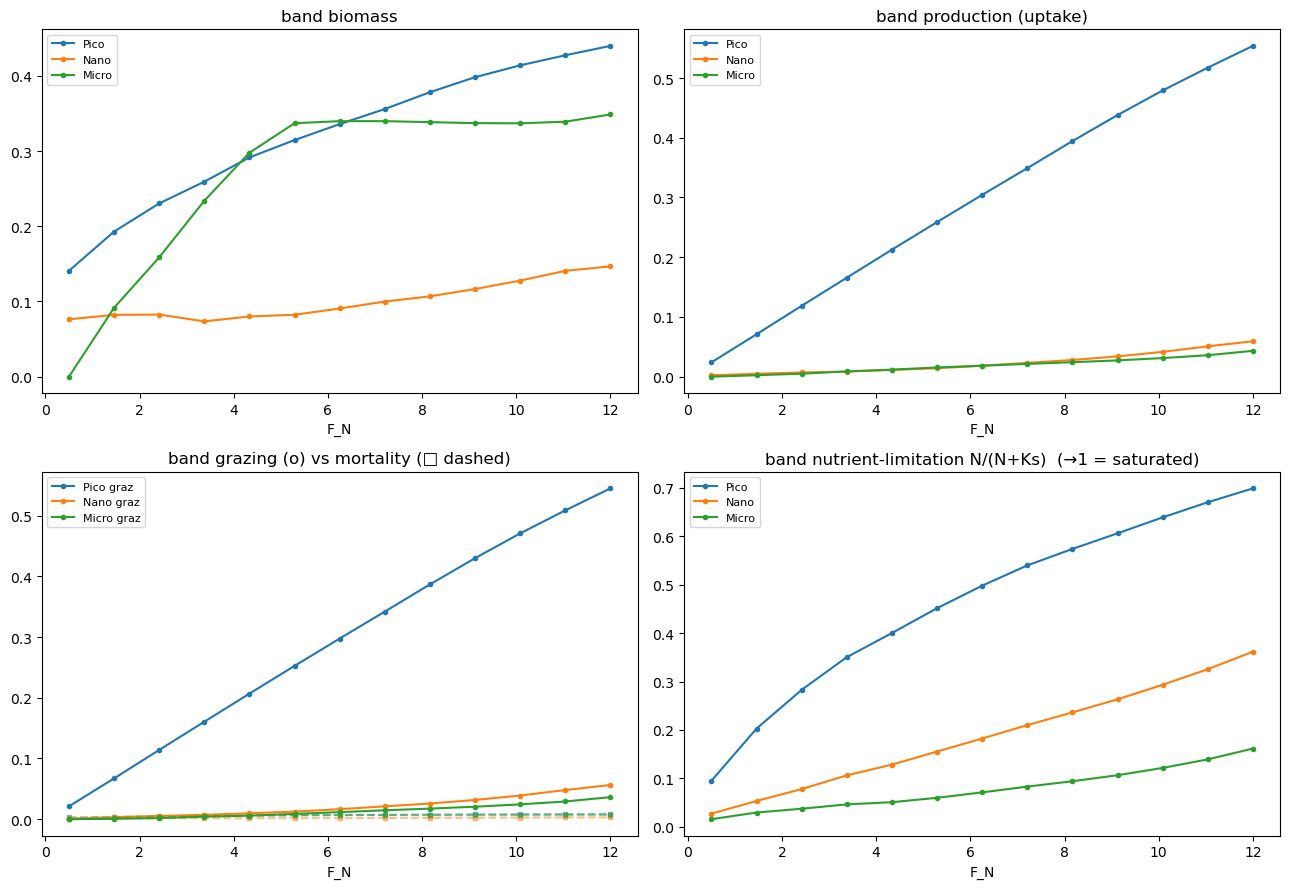

In [6]:
# ── per-band phyto budget + N/D recycling-export budget across F_N (Taniguchi + Ward 0.02, K_sZ=0.23) ──
import importlib, numpy as np, matplotlib.pyplot as plt, xso
import cariaco_npzd_setups as cns, cariaco_obs as co, parscan_utils as pu
for m in (cns, co, pu): importlib.reload(m)

pe, ze, n = cns.phyto_esd, cns.zoo_esd, cns.N_CLASSES
bin_defs, TAIL = co.TARGET_BIN_DEFINITIONS, 1000
mP_ward = np.full(n, 0.02)
*_, forc = co.load_cariaco_targets(regime='upwelling', months='hplc', agg='median', include_temperature=True)
fixed = {k: v for k, v in forc.items() if k != 'Inflow__FN'}
fTg = cns.Q10_GROW ** ((forc['Temperature__value'] - cns.T_REF) / 10.0)

OUT = {'Nutrient__value','Phytoplankton__biomass','Zooplankton__biomass','Detritus__value',
       'Growth__uptake_value','GrazingRouter__loss_P_value','PhytoMortality__mortality_value',
       'Inflow__input_value','GrazingRouter__excretion_to_N_value','GrazingRouter__egestion_to_D_value',
       'PhytoMortality__mortality_to_N_value','PhytoMortality__mortality_to_D_value',
       'ZooLinMortality__mortality_value','ZooLinMortality__mortality_to_N_value','ZooLinMortality__mortality_to_D_value',
       'ZooQuadMortality__mortality_value','ZooQuadMortality__mortality_to_N_value','ZooQuadMortality__mortality_to_D_value',
       'DetritusRemin__remineralization_value','DetritusSink__sinking_value'}
diag = xso.setup(solver='solve_ivp', model=cns.model_npzd, time=cns.ivp_time_array,
                 input_vars=cns.make_npzd_input_vars(mu_max=cns.mu_max_tani, halfsat=cns.ks_tani),
                 output_vars=OUT, solver_kwargs={**cns.IVP_SOLVER_KWARGS, 'instability_neg_threshold': -1e-3})

bands = {'Pico': pe < 2.0, 'Nano': (pe >= 2.0) & (pe < 20.0), 'Micro': pe >= 20.0}   # hard ESD cutoffs
FN_LIST = np.linspace(0.5, 12.0, 13)
tm = lambda out, nm: np.asarray(out[nm].isel(time=slice(-TAIL, None)).mean('time').values)
S  = lambda x: float(np.asarray(x).sum())

A, B, C = [], [], []
for fn in FN_LIST:
    out = pu.run_single_point(cns.model_npzd, diag, scan_params={},
              fixed_overrides={**fixed, 'Inflow__FN': float(fn), 'PhytoMortality__rate': mP_ward})
    proc = pu.process_regime_run(out, pe, ze, bin_defs, tail_len=TAIL)
    P = np.clip(tm(out,'Phytoplankton__biomass'),0,None); Z = np.clip(tm(out,'Zooplankton__biomass'),0,None)
    N = float(tm(out,'Nutrient__value')); D = float(tm(out,'Detritus__value'))
    U = tm(out,'Growth__uptake_value'); Gp = tm(out,'GrazingRouter__loss_P_value'); Mp = tm(out,'PhytoMortality__mortality_value')
    pb = np.asarray(proc['phyto_bins_tail']); fr = np.nanmedian(pb/np.clip(pb.sum(0,keepdims=True),1e-12,None),axis=1)
    A.append((fn, N, S(P), S(Z), D, proc['cv'], np.nanmedian(proc['mcs_tail']), fr[0],fr[1],fr[2],
              S(P[bands['Pico']]), S(P[bands['Nano']]), S(P[bands['Micro']])))
    bb = []
    for bm in bands.values():
        bP,bU,bG,bM = S(P[bm]),S(U[bm]),S(Gp[bm]),S(Mp[bm])
        pot = S(fTg*cns.mu_max_tani[bm]*P[bm]); nlim = bU/pot if pot>1e-12 else np.nan
        bb.append((bP,bU,bG,bM,nlim))
    B.append(bb)
    sup=float(tm(out,'Inflow__input_value')); upt=S(U)
    excrN=float(tm(out,'GrazingRouter__excretion_to_N_value')); egD=float(tm(out,'GrazingRouter__egestion_to_D_value'))
    PmN=float(tm(out,'PhytoMortality__mortality_to_N_value')); PmD=float(tm(out,'PhytoMortality__mortality_to_D_value'))
    ZlN=float(tm(out,'ZooLinMortality__mortality_to_N_value')); ZlD=float(tm(out,'ZooLinMortality__mortality_to_D_value'))
    ZqT=S(tm(out,'ZooQuadMortality__mortality_value')); ZqN=float(tm(out,'ZooQuadMortality__mortality_to_N_value')); ZqD=float(tm(out,'ZooQuadMortality__mortality_to_D_value'))
    remin=float(tm(out,'DetritusRemin__remineralization_value')); sink=float(tm(out,'DetritusSink__sinking_value'))
    recycN=excrN+PmN+ZlN+ZqN; Dgain=egD+PmD+ZlD+ZqD; Zq_exp=ZqT-ZqD-ZqN
    C.append((fn, sup, upt, recycN, remin, Dgain, sink, Zq_exp, sink+Zq_exp, sup+recycN+remin-upt))
A=np.array(A); C=np.array(C)

print("=== full state + metrics + per-band biomass ===")
print(f"{'F_N':>5}{'N':>7}{'SumP':>7}{'SumZ':>7}{'D':>7}{'cv':>5}{'mcs':>5}{'Pi':>5}{'Na':>5}{'Mi':>5}{'Ppic':>6}{'Pnan':>6}{'Pmic':>6}")
for r in A: print(f"{r[0]:5.1f}{r[1]:7.3f}{r[2]:7.3f}{r[3]:7.3f}{r[4]:7.3f}{r[5]:5.2f}{r[6]:5.1f}{r[7]:5.2f}{r[8]:5.2f}{r[9]:5.2f}{r[10]:6.3f}{r[11]:6.3f}{r[12]:6.3f}")

print("\n=== N & D mass budget (recycling / detritus / export) ===")
print(f"{'F_N':>5}{'supply':>8}{'uptake':>8}{'recyc>N':>8}{'remin':>8}{'D_gain':>8}{'sink':>8}{'Zq_exp':>8}{'export':>8}{'Nnet':>9}")
for r in C: print(f"{r[0]:5.1f}{r[1]:8.4f}{r[2]:8.4f}{r[3]:8.4f}{r[4]:8.4f}{r[5]:8.4f}{r[6]:8.4f}{r[7]:8.4f}{r[8]:8.4f}{r[9]:9.1e}")

fig, ax = plt.subplots(2,2, figsize=(13,9)); cols={'Pico':'tab:blue','Nano':'tab:orange','Micro':'tab:green'}; bn=list(bands)
for bi,bname in enumerate(bn):
    bio=[B[k][bi][0] for k in range(len(FN_LIST))]; prod=[B[k][bi][1] for k in range(len(FN_LIST))]
    grz=[B[k][bi][2] for k in range(len(FN_LIST))]; mor=[B[k][bi][3] for k in range(len(FN_LIST))]; nlim=[B[k][bi][4] for k in range(len(FN_LIST))]
    ax[0,0].plot(FN_LIST,bio,'o-',ms=3,c=cols[bname],label=bname)
    ax[0,1].plot(FN_LIST,prod,'o-',ms=3,c=cols[bname],label=bname)
    ax[1,0].plot(FN_LIST,grz,'o-',ms=3,c=cols[bname],label=f'{bname} graz'); ax[1,0].plot(FN_LIST,mor,'s--',ms=3,c=cols[bname],alpha=.5)
    ax[1,1].plot(FN_LIST,nlim,'o-',ms=3,c=cols[bname],label=bname)
ax[0,0].set_title('band biomass'); ax[0,1].set_title('band production (uptake)')
ax[1,0].set_title('band grazing (o) vs mortality (□ dashed)'); ax[1,1].set_title('band nutrient-limitation N/(N+Ks)  (→1 = saturated)')
for a in ax.flat: a.set_xlabel('F_N'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

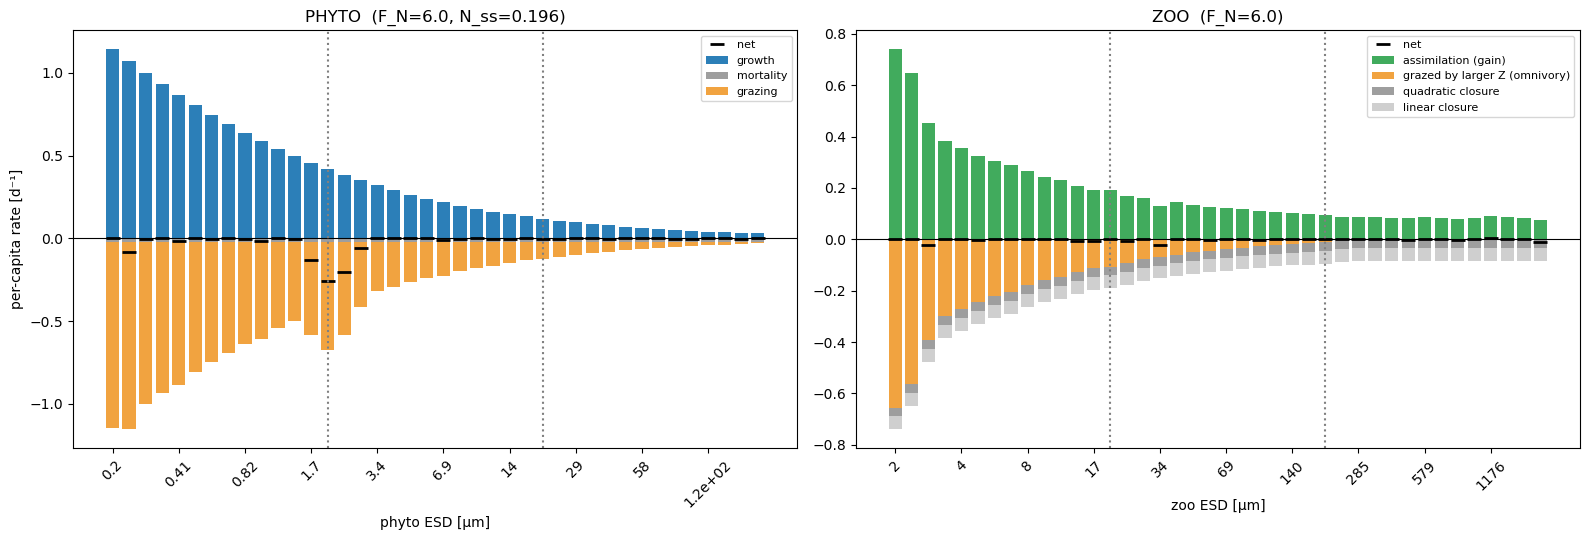

F_N=6.0  N_ss=0.1956  ΣP=0.758  ΣZ=0.346


In [8]:
# ── per-class gains-vs-losses budget, P and Z (flux_plot style), Taniguchi+Ward construct ──
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_npzd_setups as cns, cariaco_obs as co, parscan_utils as pu
for m in (cns, co, pu): importlib.reload(m)

REGIME, TAIL, FN_SHOW = 'upwelling', 1000, 6.0        # change FN_SHOW to inspect other supply levels
pe, ze, n = cns.phyto_esd, cns.zoo_esd, cns.N_CLASSES
mu, ks = cns.mu_max_tani, cns.ks_tani                  # Taniguchi growth
mP_val, Imax, KsZ, phi = 0.02, cns.Imax_arr, cns.K_SZ, cns.phiPZ_omni   # Ward mortality, Dutk grazing
GGE, mZ, mZl = cns.GGE_VAL, cns.M_Z, cns.M_ZLIN

*_, forc = co.load_cariaco_targets(regime=REGIME, months='hplc', agg='median', include_temperature=True)
fixed = {k: v for k, v in forc.items() if k != 'Inflow__FN'}
fTg = cns.Q10_GROW ** ((forc['Temperature__value'] - cns.T_REF)/10)
fTz = cns.Q10_GRAZE ** ((forc['Temperature__value'] - cns.T_REF)/10)

out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_tani_slim, scan_params={},
          fixed_overrides={**fixed, 'Inflow__FN': FN_SHOW, 'PhytoMortality__rate': np.full(n, mP_val),
                           'Grazing__KsZ': np.full(n, KsZ)})
P = np.clip(np.asarray(out['Phytoplankton__biomass'].isel(time=slice(-TAIL,None)).mean('time').values),0,None)
Z = np.clip(np.asarray(out['Zooplankton__biomass'].isel(time=slice(-TAIL,None)).mean('time').values),0,None)
Nss = float(np.asarray(out['Nutrient__value'].isel(time=slice(-TAIL,None)).mean('time').values))

B = np.concatenate([P, Z]); Ssat = (phi*B[:,None]).sum(0)
type3 = Ssat/(Ssat**2 + KsZ**2)
graze_press = (fTz*Imax[None,:]*Z[None,:]*phi*type3[None,:]).sum(1)     # per-capita grazing pressure on every prey (2n)

P_growth = fTg*mu*Nss/(Nss+ks); P_mort = np.full(n, mP_val); P_graze = graze_press[:n]
P_net = P_growth - P_mort - P_graze
Z_gain = GGE*fTz*Imax*Ssat**2/(Ssat**2+KsZ**2); Z_graze = graze_press[n:]
Z_quad = mZ*Z.sum()*np.ones(n); Z_lin = np.full(n, mZl)
Z_net = Z_gain - Z_graze - Z_quad - Z_lin

fig, ax = plt.subplots(1, 2, figsize=(16, 5.5)); x = np.arange(n)
ax[0].bar(x, P_growth, color='#2c7fb8', label='growth')
ax[0].bar(x, -P_mort, color='#9e9e9e', label='mortality')
ax[0].bar(x, -P_graze, bottom=-P_mort, color='#f1a340', label='grazing')
ax[0].plot(x, P_net, 'k_', ms=10, mew=2, label='net'); ax[0].axhline(0,c='k',lw=.8)
for b in (2,20): ax[0].axvline(np.interp(np.log10(b), np.log10(pe), x), c='grey', ls=':')
ax[0].set_xticks(x[::4]); ax[0].set_xticklabels([f'{e:.2g}' for e in pe[::4]], rotation=45)
ax[0].set_xlabel('phyto ESD [µm]'); ax[0].set_ylabel('per-capita rate [d⁻¹]'); ax[0].set_title(f'PHYTO  (F_N={FN_SHOW}, N_ss={Nss:.3f})'); ax[0].legend(fontsize=8)
ax[1].bar(x, Z_gain, color='#41ab5d', label='assimilation (gain)')
ax[1].bar(x, -Z_graze, color='#f1a340', label='grazed by larger Z (omnivory)')
ax[1].bar(x, -Z_quad, bottom=-Z_graze, color='#9e9e9e', label='quadratic closure')
ax[1].bar(x, -Z_lin, bottom=-(Z_graze+Z_quad), color='#cfcfcf', label='linear closure')
ax[1].plot(x, Z_net, 'k_', ms=10, mew=2, label='net'); ax[1].axhline(0,c='k',lw=.8)
for b in (20,200): ax[1].axvline(np.interp(np.log10(b), np.log10(ze), x), c='grey', ls=':')
ax[1].set_xticks(x[::4]); ax[1].set_xticklabels([f'{e:.0f}' for e in ze[::4]], rotation=45)
ax[1].set_xlabel('zoo ESD [µm]'); ax[1].set_title(f'ZOO  (F_N={FN_SHOW})'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"F_N={FN_SHOW}  N_ss={Nss:.4f}  ΣP={P.sum():.3f}  ΣZ={Z.sum():.3f}")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 12 points using 8 workers...
1D Scan complete. Time taken: 19.72837 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 12 points using 8 workers...
1D Scan complete. Time taken: 18.9444 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 12 points using 8 w

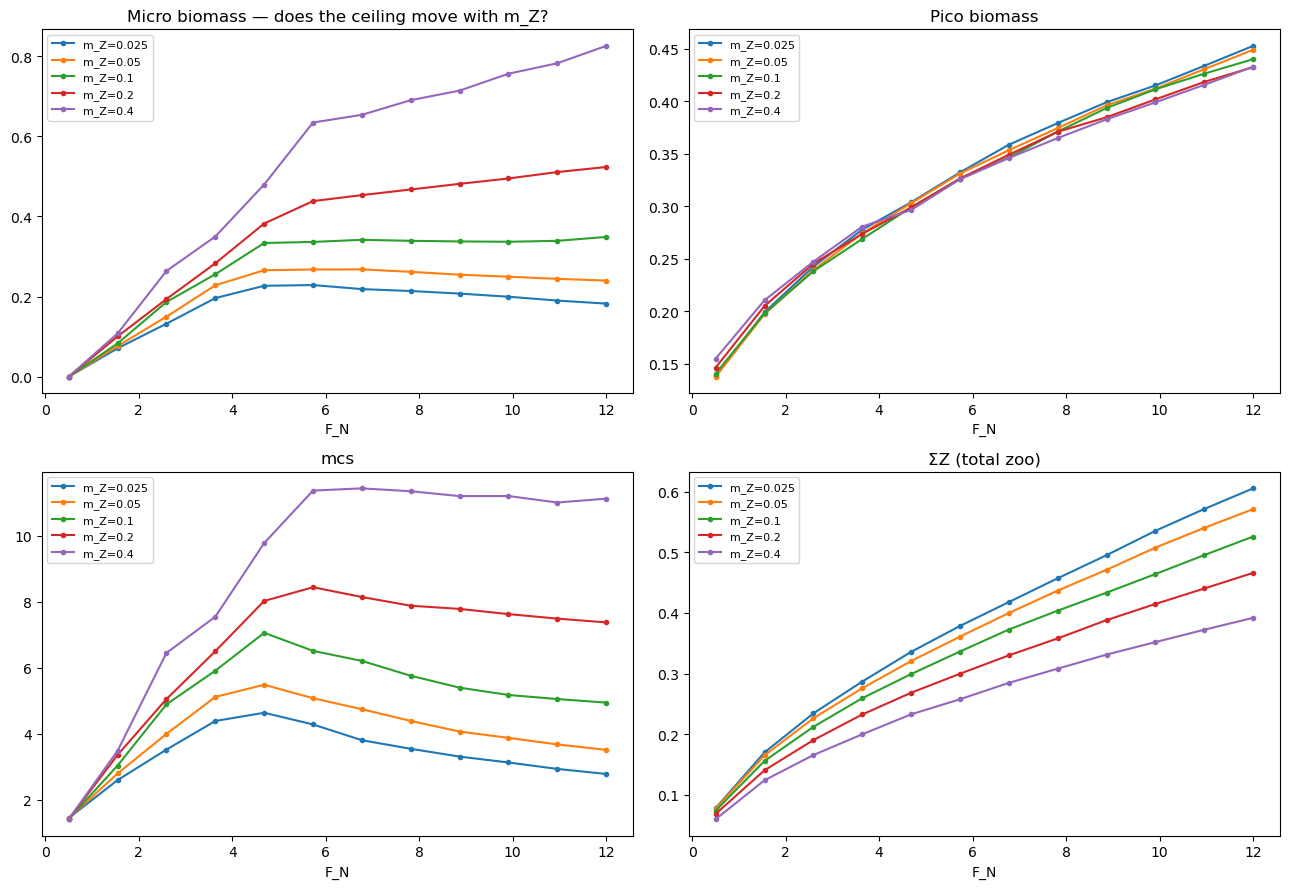

In [7]:
# ── m_Z (quadratic closure) × F_N: does the Micro-biomass ceiling move with the closure? ──
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_npzd_setups as cns, cariaco_obs as co, parscan_utils as pu
for m in (cns, co, pu): importlib.reload(m)
from xso.parscans import run_xso_parscan

pe, ze, n = cns.phyto_esd, cns.zoo_esd, cns.N_CLASSES
bin_defs, TAIL = co.TARGET_BIN_DEFINITIONS, 1000
mP_ward, ksz23 = np.full(n, 0.02), np.full(n, 0.23)
*_, forc = co.load_cariaco_targets(regime='upwelling', months='hplc', agg='median', include_temperature=True)
fixed = {k: v for k, v in forc.items() if k != 'Inflow__FN'}
micro, pico = pe >= 20.0, pe < 2.0

MZ_LIST   = [0.025, 0.05, 0.1, 0.2, 0.4]
FN_VALUES = np.linspace(0.5, 12.0, 12)
res_by_mz = {}
for mz in MZ_LIST:
    res = run_xso_parscan(model_file_name='cariaco_npzd_setups', model_name='model_npzd',
            model_setup_name='model_setup_npzd_tani_scan',
            param_name='Inflow__FN', param_values=FN_VALUES, processes=8,
            fixed_overrides={**fixed, 'PhytoMortality__rate': mP_ward, 'Grazing__KsZ': ksz23, 'ZooQuadMortality__rate': mz})
    rows = []
    for k in range(len(FN_VALUES)):
        cell = res.isel({'Inflow__FN': k})
        proc = pu.process_regime_run(cell, pe, ze, bin_defs, tail_len=TAIL)
        P = np.clip(np.asarray(cell['Phytoplankton__biomass'].isel(time=slice(-TAIL,None)).mean('time').values), 0, None)
        Z = np.clip(np.asarray(cell['Zooplankton__biomass'].isel(time=slice(-TAIL,None)).mean('time').values), 0, None)
        N = float(np.asarray(cell['Nutrient__value'].isel(time=slice(-TAIL,None)).mean('time').values))
        D = float(np.asarray(cell['Detritus__value'].isel(time=slice(-TAIL,None)).mean('time').values))
        pb = np.asarray(proc['phyto_bins_tail']); fr = np.nanmedian(pb/np.clip(pb.sum(0,keepdims=True),1e-12,None),axis=1)
        rows.append((FN_VALUES[k], np.nanmedian(proc['mcs_tail']), fr[0],fr[1],fr[2], proc['cv'],
                     N, P.sum(), Z.sum(), D, P[pico].sum(), P[micro].sum()))
    res_by_mz[mz] = np.array(rows)

print(f"{'m_Z':>6}{'Pmic@12':>9}{'mcs@12':>8}{'Mi@12':>7}{'SumZ@12':>9}{'peak_mcs':>9}{'@F_N':>6}")
for mz in MZ_LIST:
    r = res_by_mz[mz]; pk = int(np.nanargmax(r[:,1]))
    print(f"{mz:6.3f}{r[-1,11]:9.3f}{r[-1,1]:8.1f}{r[-1,4]:7.2f}{r[-1,8]:9.3f}{r[pk,1]:9.1f}{r[pk,0]:6.1f}")

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
for mz in MZ_LIST:
    r = res_by_mz[mz]
    ax[0,0].plot(r[:,0], r[:,11], 'o-', ms=3, label=f'm_Z={mz}')   # Micro biomass
    ax[0,1].plot(r[:,0], r[:,10], 'o-', ms=3, label=f'm_Z={mz}')   # Pico biomass
    ax[1,0].plot(r[:,0], r[:,1],  'o-', ms=3, label=f'm_Z={mz}')   # mcs
    ax[1,1].plot(r[:,0], r[:,8],  'o-', ms=3, label=f'm_Z={mz}')   # ΣZ
ax[0,0].set_title('Micro biomass — does the ceiling move with m_Z?'); ax[0,1].set_title('Pico biomass')
ax[1,0].set_title('mcs'); ax[1,1].set_title('ΣZ (total zoo)')
for a in ax.flat: a.set_xlabel('F_N'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()